In [113]:
import os
import seaborn
import matplotlib.pyplot as plt
import json
import numpy as np
from collections import defaultdict
import h5py

In [133]:
USER = "chengshu"
ROOT_DIR = "/mnt"
PROJECT = "momagen"

TASK = "tidy_table"
DR = "D0"
# ABLATIONS = ["full"]
ABLATIONS = ["no_vis", "only_hard", "only_soft", "full"]
# ABLATIONS = ["no_vis", "only_hard"]
# ABLATIONS = ["no_vis"]
TOTAL_DEMOS = 2000

In [147]:
for ABLATION in ABLATIONS:
    FOLDER = f"{TASK}_{ABLATION}"
    if TASK == "tidy_table" and ABLATION == "full":
        PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}_old"
    else:
        PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}"
    for folder in sorted(os.listdir(PATH)):
        print(ABLATION, folder)
        folder_path = os.path.join(PATH, folder)
        for subfolder in sorted(os.listdir(folder_path)):
            if DR not in subfolder: continue
            stats_json_file = os.path.join(folder_path, subfolder, "subtask_lengths.json")
            demo_hdf5_file = os.path.join(folder_path, subfolder, "demo.hdf5")
            if os.path.isfile(stats_json_file): continue
            subtask_lengths = dict()
            if not os.path.isfile(demo_hdf5_file): continue
            with h5py.File(demo_hdf5_file, "r") as hdf5_f:
                for demo_key in hdf5_f["data"]:
                    subtask_lengths[demo_key] = hdf5_f["data"][demo_key]["subtask_lengths"][:].tolist()
            with open(stats_json_file, "w+") as f:
                json.dump(subtask_lengths, f)

no_vis r1_tidy_table_worker_0
no_vis r1_tidy_table_worker_1
no_vis r1_tidy_table_worker_2
no_vis r1_tidy_table_worker_3
no_vis r1_tidy_table_worker_4
no_vis r1_tidy_table_worker_5
no_vis r1_tidy_table_worker_6
no_vis r1_tidy_table_worker_7
no_vis r1_tidy_table_worker_8
no_vis r1_tidy_table_worker_9
only_hard r1_tidy_table_worker_0
only_hard r1_tidy_table_worker_1
only_hard r1_tidy_table_worker_10
only_hard r1_tidy_table_worker_11
only_hard r1_tidy_table_worker_12
only_hard r1_tidy_table_worker_13
only_hard r1_tidy_table_worker_14
only_hard r1_tidy_table_worker_15
only_hard r1_tidy_table_worker_16
only_hard r1_tidy_table_worker_17
only_hard r1_tidy_table_worker_18
only_hard r1_tidy_table_worker_19
only_hard r1_tidy_table_worker_2
only_hard r1_tidy_table_worker_3
only_hard r1_tidy_table_worker_4
only_hard r1_tidy_table_worker_5
only_hard r1_tidy_table_worker_6
only_hard r1_tidy_table_worker_7
only_hard r1_tidy_table_worker_8
only_hard r1_tidy_table_worker_9
only_soft r1_tidy_table_worker

In [148]:
num_success = defaultdict(list)
num_attempts = defaultdict(list)
visibility_perc = defaultdict(list)
episode_length = defaultdict(list)

for ABLATION in ABLATIONS:
    FOLDER = f"{TASK}_{ABLATION}"
    if TASK == "tidy_table" and ABLATION == "full":
        PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}_old"
    else:
        PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}"
    for folder in sorted(os.listdir(PATH)):
        print(ABLATION, folder)
        folder_path = os.path.join(PATH, folder)
        for subfolder in sorted(os.listdir(folder_path)):
            if DR not in subfolder: continue
            stats_json_file = os.path.join(folder_path, subfolder, "important_stats.json")
            subtask_json_file = os.path.join(folder_path, subfolder, "subtask_lengths.json")
    
            if os.path.exists(stats_json_file):
                with open(stats_json_file) as f:
                    data = json.load(f)

                num_success[ABLATION].append(data["num_success"])
                num_attempts[ABLATION].append(data["num_attempts"])

                all_episode_logs = data["all_episode_logs"]
                success_episode_id = 0

                with open(subtask_json_file) as f:
                    subtask_data = json.load(f)

                for task_success, phase_logs in zip(all_episode_logs["task_success"], all_episode_logs["phase_logs"]):
                    if not task_success: continue
                    # print(len(phase_logs))
                    # this should not happen, debug!
                    if len(phase_logs) == 0: continue
                    subtask_lengths = subtask_data[f"demo_{success_episode_id}"]
                    num_visible_frames = 0
                    num_total_frames = 0
                    for phase_id, phase_log in enumerate(phase_logs.values()):
                        if phase_log["phase_type"] != "navigation": continue
                        # print(phase_id)
                        # Legacy: just head camera for navigation
                        # print(phase_log)
                        # assert False
                        if "num_frames_with_obj_visible" in phase_log:
                            num_visible_frames += phase_log["num_frames_with_obj_visible"] * subtask_lengths[phase_id]
                        elif "visibility_stats" in phase_log:
                            for key in phase_log["visibility_stats"]:
                                if "eye" in key and "nav" in key:
                                    num_visible_frames += phase_log["visibility_stats"][key] * subtask_lengths[phase_id]
                        num_total_frames += subtask_lengths[phase_id]
                    visibility_perc[ABLATION].append(num_visible_frames / num_total_frames)
                    success_episode_id += 1


no_vis r1_tidy_table_worker_0
no_vis r1_tidy_table_worker_1
no_vis r1_tidy_table_worker_2
no_vis r1_tidy_table_worker_3
no_vis r1_tidy_table_worker_4
no_vis r1_tidy_table_worker_5
no_vis r1_tidy_table_worker_6
no_vis r1_tidy_table_worker_7
no_vis r1_tidy_table_worker_8
no_vis r1_tidy_table_worker_9
only_hard r1_tidy_table_worker_0
only_hard r1_tidy_table_worker_1
only_hard r1_tidy_table_worker_10
only_hard r1_tidy_table_worker_11
only_hard r1_tidy_table_worker_12
only_hard r1_tidy_table_worker_13
only_hard r1_tidy_table_worker_14
only_hard r1_tidy_table_worker_15
only_hard r1_tidy_table_worker_16
only_hard r1_tidy_table_worker_17
only_hard r1_tidy_table_worker_18
only_hard r1_tidy_table_worker_19
only_hard r1_tidy_table_worker_2
only_hard r1_tidy_table_worker_3
only_hard r1_tidy_table_worker_4
only_hard r1_tidy_table_worker_5
only_hard r1_tidy_table_worker_6
only_hard r1_tidy_table_worker_7
only_hard r1_tidy_table_worker_8
only_hard r1_tidy_table_worker_9
only_soft r1_tidy_table_worker

no_vis success_rate 0.7380073800738007
no_vis avg_visibility_perc 0.46713492098479314
only_hard success_rate 0.78125
only_hard avg_visibility_perc 0.6391170943183826
only_soft success_rate 0.5936675461741425
only_soft avg_visibility_perc 0.6301855514271321
full success_rate 0.7990411506192568
full avg_visibility_perc 0.8609871443583537


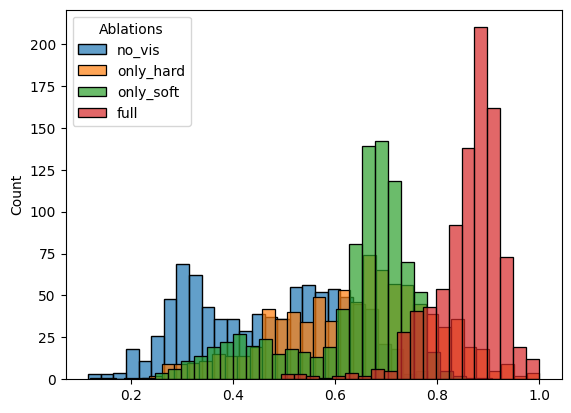

In [149]:
success_rate_list = []
avg_visibility_perc_list = []
for ABLATION in ABLATIONS:
    total_successes = np.sum(num_success[ABLATION])
    total_attempts = np.sum(num_attempts[ABLATION])
    # print(ABLATION, total_successes)
    # assert total_successes == TOTAL_DEMOS
    success_rate = total_successes / total_attempts
    print(ABLATION, "success_rate", success_rate)
    success_rate_list.append(success_rate)
    # print(ABLATION, len(visibility_perc[ABLATION]))
    # assert len(visibility_perc[ABLATION]) == total_successes
    # print(visibility_perc[ABLATION])
    seaborn.histplot(visibility_perc[ABLATION][:900], binwidth=0.025, alpha=0.7, label=ABLATION, legend=True)
    avg_visibility_perc = np.mean(visibility_perc[ABLATION][:900])
    print(ABLATION, "avg_visibility_perc", avg_visibility_perc)
    avg_visibility_perc_list.append(avg_visibility_perc)
    # print((np.array(visibility_perc[ABLATION]) < 0.8).sum())

plt.legend(title='Ablations')

<Axes: xlabel='methods', ylabel='success_rate'>

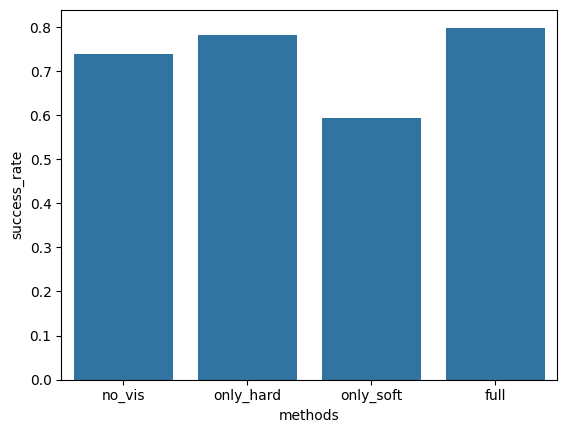

In [150]:
data = {
    "methods": ABLATIONS,
    "success_rate": success_rate_list,
}

seaborn.barplot(x="methods", y="success_rate", data=data)

<Axes: xlabel='methods', ylabel='avg_visibility_perc'>

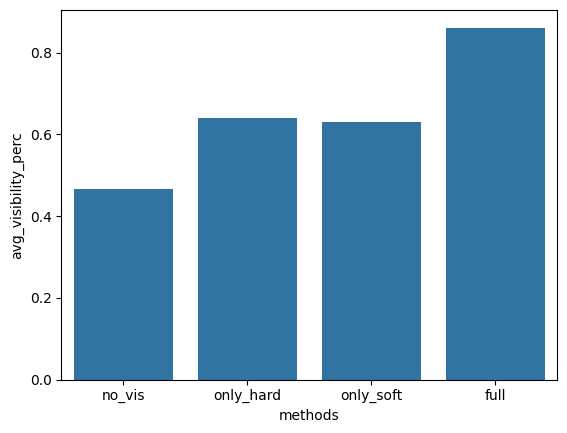

In [151]:
data = {
    "methods": ABLATIONS,
    "avg_visibility_perc": avg_visibility_perc_list,
}

seaborn.barplot(x="methods", y="avg_visibility_perc", data=data)